In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x)) - 0.5
def euler_integrate(A, r_init, dt=0.1, T=100):
    N = len(r_init)
    r = np.zeros((T, N))
    r[0] = r_init
    
    for t in range(1, T):
        dr_dt = -r[t-1] + sigmoid(A @ r[t-1])
        r[t] = r[t-1] + dt * dr_dt
    
    return r

def fully_connected(N, J):
    return np.full((N, N), J / N)

def erdos_renyi(N, J, p):
    k = max(1, int(p * N))
    A = (np.random.rand(N, N) < p).astype(float) * (J / k)
    np.fill_diagonal(A, 0)
    return A

def gaussian_random(N, J):
    A = np.random.normal(0, J**2 / N, (N, N))
    np.fill_diagonal(A, 0)
    return A

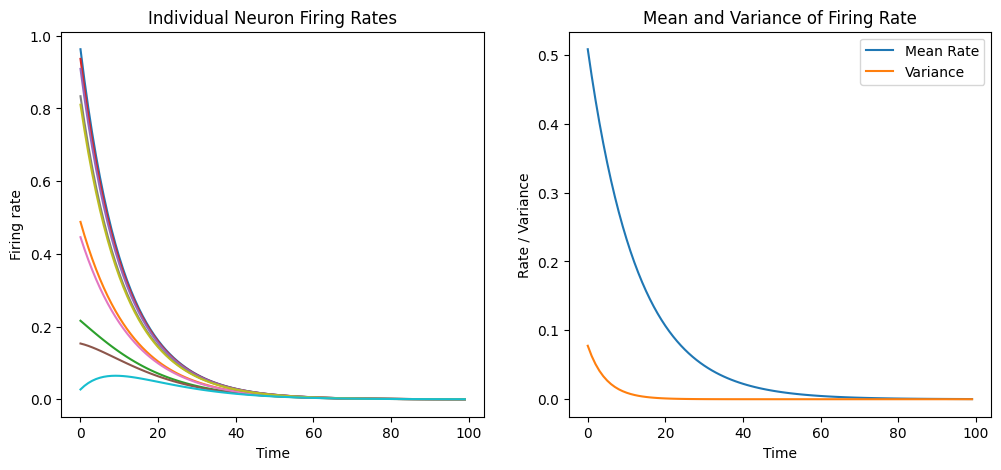

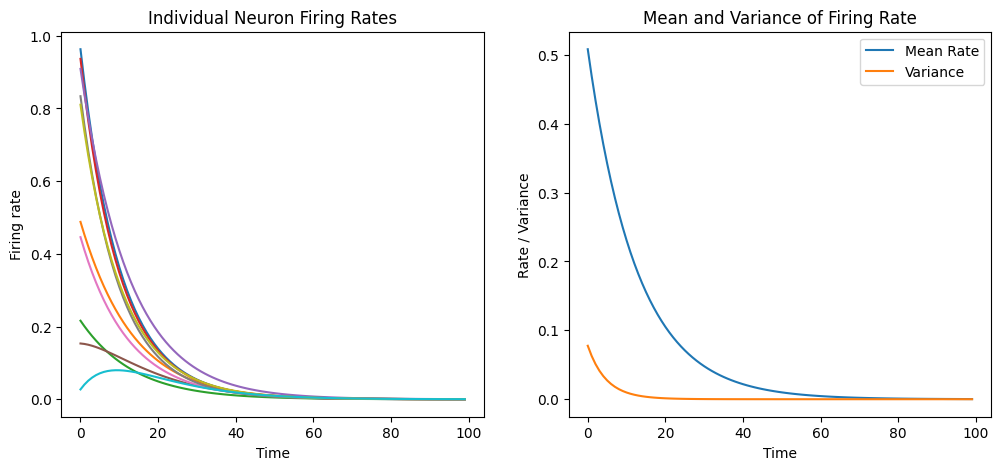

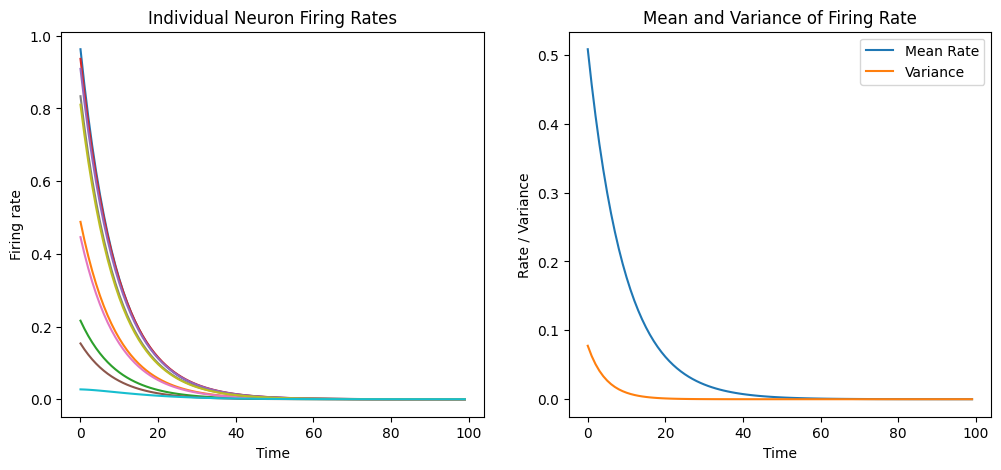

In [3]:
def plot_results(r):
    T, N = r.shape
    mean_rate = np.mean(r, axis=1)
    variance = np.var(r, axis=1)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(r[:, :min(N, 10)])
    plt.xlabel("Time")
    plt.ylabel("Firing rate")
    plt.title("Individual Neuron Firing Rates")
    
    plt.subplot(1, 2, 2)
    plt.plot(mean_rate, label="Mean Rate")
    plt.plot(variance, label="Variance")
    plt.xlabel("Time")
    plt.ylabel("Rate / Variance")
    plt.legend()
    plt.title("Mean and Variance of Firing Rate")
    plt.show()

# Parameters
N = 100
J = 1.0
dt = 0.1
T = 100
r_init = np.random.rand(N)

# Fully Connected Network
A_fc = fully_connected(N, J)
r_fc = euler_integrate(A_fc, r_init, dt, T)
plot_results(r_fc)

# Erdos-Renyi Network
p = 0.1
A_er = erdos_renyi(N, J, p)
r_er = euler_integrate(A_er, r_init, dt, T)
plot_results(r_er)

# Gaussian Random Network
A_gr = gaussian_random(N, J)
r_gr = euler_integrate(A_gr, r_init, dt, T)
plot_results(r_gr)
